In [ ]:
!pip install matplotlib numpy pandas scikit-learn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
df = pd.read_csv("iris.csv")
print(df.info)

<bound method DataFrame.info of      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
0              5.1           3.5            1.4           0.2     Iris-setosa
1              4.9           3.0            1.4           0.2     Iris-setosa
2              4.7           3.2            1.3           0.2     Iris-setosa
3              4.6           3.1            1.5           0.2     Iris-setosa
4              5.0           3.6            1.4           0.2     Iris-setosa
..             ...           ...            ...           ...             ...
145            6.7           3.0            5.2           2.3  Iris-virginica
146            6.3           2.5            5.0           1.9  Iris-virginica
147            6.5           3.0            5.2           2.0  Iris-virginica
148            6.2           3.4            5.4           2.3  Iris-virginica
149            5.9           3.0            5.1           1.8  Iris-virginica

[150 rows x 5 columns]>


In [10]:
print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [14]:
print(df.describe())

       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000


In [15]:
print(df.tail())

     SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm         Species
145            6.7           3.0            5.2           2.3  Iris-virginica
146            6.3           2.5            5.0           1.9  Iris-virginica
147            6.5           3.0            5.2           2.0  Iris-virginica
148            6.2           3.4            5.4           2.3  Iris-virginica
149            5.9           3.0            5.1           1.8  Iris-virginica


In [16]:
print(df.sample(5))

    SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm          Species
9             4.9           3.1            1.5           0.1      Iris-setosa
86            6.7           3.1            4.7           1.5  Iris-versicolor
36            5.5           3.5            1.3           0.2      Iris-setosa
75            6.6           3.0            4.4           1.4  Iris-versicolor
5             5.4           3.9            1.7           0.4      Iris-setosa


In [18]:
print(df.isnull().sum())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


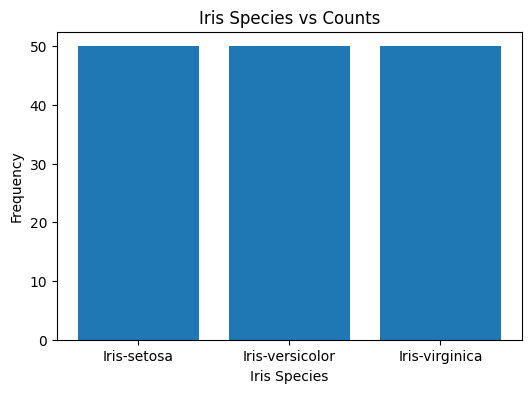

In [26]:
counts = df['Species'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(x=counts.index, height=counts.values)
plt.xlabel("Iris Species")
plt.ylabel("Frequency")
plt.title("Iris Species vs Counts")
plt.savefig("barchart.png")
plt.show()

In [31]:
from sklearn.model_selection import train_test_split 

In [34]:
#Split the dataset into X and y
X = df.drop(columns=['Species'])
y = df['Species']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Length of X_train and y_train = {X_train.shape} {y_train.shape}")
print(f"Length of X_test and y_test = {X_test.shape} {y_test.shape}")

Length of X_train and y_train = (120, 4) (120,)
Length of X_test and y_test = (30, 4) (30,)


In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [37]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_preds = knn.predict(X_test)
print(f"Accuracy = {accuracy_score(y_test, y_preds)}")
print(f"classification Report\n {classification_report(y_test,y_preds)}")

Accuracy = 1.0
classification Report
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



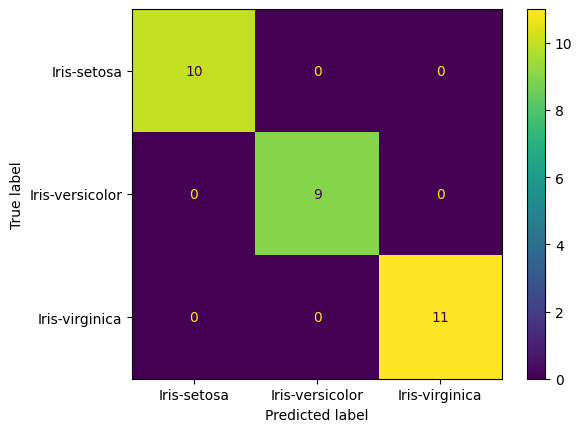

In [38]:
cm = confusion_matrix(y_test, y_preds)
cm_plot = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=df['Species'].unique()    
)

cm_plot.plot()
plt.savefig("cm.png")
plt.show()

In [41]:
import joblib 
joblib.dump(knn,"knn_model.joblib")
print("SUCCESS")

SUCCESS


In [43]:
sample = X_test.sample()
sample_preds = knn.predict(sample)
print(sample_preds[0])

Iris-versicolor
